[mfd_buyamt_nd测试] [1/2] 开始计算20日累计因子的基础指标...
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 3,758,953 行 | 已耗时 10.9s                                                                                                                                
[BigQuant loader] 1/1（100.00%），数据域合并完成，当前 security_daily，3,758,953 行，耗时 12.1s                                                                                                      
[mfd_buyamt_nd] [2/2] 36/36 个截面 | 100.0% | 当前：2026-05-12 | 累计值有效：5,106 | 输出有效：5,106 | 已耗时：12.5s | 预计剩余：0.0s                                                                                             
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 193,777 行 | 已耗时 0.3s                                                                                                                                   
[因子基础指标] [8/8] 绘制并展示IC/RankIC时序图 | 已耗时 36.5s                                                                                                                                 

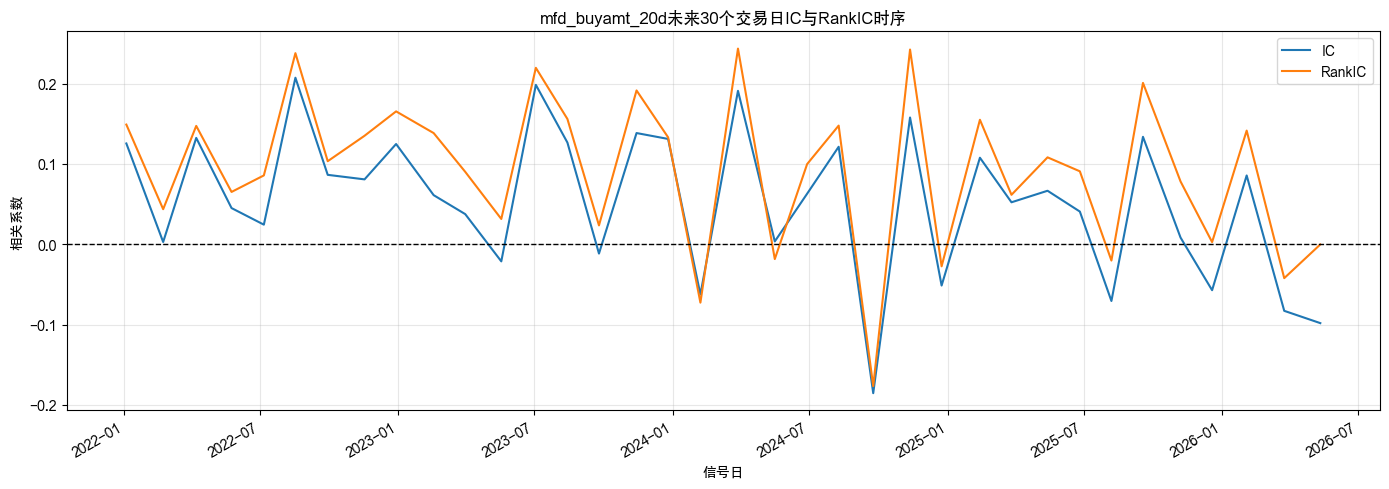



mfd_buyamt_nd基础指标汇总：


,factor_column,ic_mean,icir,rank_ic_mean,rank_icir,factor_return_mean,mean_t_value,cross_section_count,valid_ic_count
0,mfd_buyamt_nd,0.053082,0.577331,0.092463,0.964064,0.005712,3.704239,36,36


mfd_buyamt_nd最近10个有效评价截面：


,signal_date,return_end_date,sample_count,ic,rank_ic,factor_return,factor_t_value
26,2025-03-27,2025-05-14,5073,0.052189,0.061498,0.006833,3.721469
27,2025-05-14,2025-06-26,5023,0.066548,0.108152,0.008929,4.725987
28,2025-06-26,2025-08-07,5086,0.040633,0.090758,0.008940,2.899634
29,2025-08-07,2025-09-18,5111,-0.070705,-0.020354,-0.013321,-5.066486
30,2025-09-18,2025-11-07,5121,0.133708,0.200834,0.021477,9.653137
31,2025-11-07,2025-12-19,5116,0.008251,0.078130,0.001136,0.590046
32,2025-12-19,2026-02-03,5116,-0.057282,0.002602,-0.011089,-4.103094
33,2026-02-03,2026-03-25,5141,0.085580,0.141455,0.013542,6.157538
34,2026-03-25,2026-05-12,5142,-0.082968,-0.042270,-0.018244,-5.968848
35,2026-05-12,2026-06-24,5086,-0.098276,-0.000316,-0.023812,-7.041406


[mfd_buyamt_nd测试] [2/2] 开始20日累计因子的市值分组回测...
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 3,868,884 行 | 已耗时 10.0s                                                                                                                                                    
[BigQuant loader] 1/1（100.00%），数据域合并完成，当前 security_daily，3,868,884 行，耗时 11.0s                                                                                                      
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 193,740 行 | 已耗时 4.3s                                                                                                                                                       
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 193,777 行 | 已耗时 3.6s                                                                                                                                                       
[市值分组回测] [6/8] 启动 BigTrader 原生回测 | 0/37 (0.0%) | 37个信号，5,709只候选股票 | 已耗时 29.5s                                    

[2026-08-04 16:37:25] [info     ] bigtrader.v35 运行完成 [113.408s].
[市值分组回测] [8/8] 回测与审计结果整理完成 | 1/1 (100.0%) | 信号17,897条，订单26,258条，成交13,129条 | 已耗时 143.9s                                                                                                                                      


In [1]:
# -*- coding: utf-8 -*-
"""mfd_buyamt_nd 基础指标、IC时序图与市值分组回测测试。"""

import sys

sys.dont_write_bytecode = True

from IPython.display import display

from factor_lib.function.bigquant_function.factor_evaluation.calculate_factor_basic_metrics import (
    calculate_factor_basic_metrics,
)
from factor_lib.function.bigquant_function.strategies.market_cap_group_backtest import (
    run_market_cap_group_backtest,
)


# ============================================================
# 1. 公共研究参数
# ============================================================

START_DATE = "2022-01-01"
END_DATE = "2026-06-30"

# 每30个交易日评价一次；未来30个交易日收益作为评价标签。
EVALUATION_FREQUENCY = 30

# 每30个交易日调仓；信号在执行日前一交易日收盘后形成。
REBALANCE_INTERVAL = 30

MIN_OBS = 30
SHOW_PROGRESS = True
PROGRESS_EVERY = 5


# ============================================================
# 2. mfd_buyamt_nd 因子参数
# ============================================================

FACTOR_NAME = "mfd_buyamt_nd"

# 这里测试20日累计实例；改成1即可复现原mfd_buyamt_d单日实例。
N_DAYS = 20

FACTOR_PARAMS = {
    "n_days": N_DAYS,

    # None表示要求窗口内N个交易日的资金流数据全部有效。
    "min_observations": None,

    # True表示同时进行流通市值和行业中性化。
    "neutralize_industry": True,

    # 原始截面和中性化残差均使用scaled-MAD去极值。
    "winsor_k": 3.0,

    # 单个截面执行中性化所需的最少有效股票数。
    "min_cs_count": 30,
}


# ============================================================
# 3. 自动计算基础指标并展示IC/RankIC时序图
# ============================================================

print(
    f"[mfd_buyamt_nd测试] [1/2] 开始计算{N_DAYS}日累计因子的基础指标..."
)

mfd_buyamt_metrics = calculate_factor_basic_metrics(
    start_date=START_DATE,
    end_date=END_DATE,
    frequency=EVALUATION_FREQUENCY,
    factor_name=FACTOR_NAME,
    factor_params=FACTOR_PARAMS,
    instruments=None,  # None表示由适配器读取全部A股。
    min_obs=MIN_OBS,
    plot=True,
    plot_title=(
        f"mfd_buyamt_{N_DAYS}d未来{EVALUATION_FREQUENCY}个交易日"
        "IC与RankIC时序"
    ),
    figsize=(14, 5),
    show_progress=SHOW_PROGRESS,
    progress_every=PROGRESS_EVERY,
)

print("\nmfd_buyamt_nd基础指标汇总：")
display(mfd_buyamt_metrics["summary"])

print("mfd_buyamt_nd最近10个有效评价截面：")
display(mfd_buyamt_metrics["timeseries"].tail(10))


# ============================================================
# 4. 市值分组等权回测
# ============================================================

print(
    f"[mfd_buyamt_nd测试] [2/2] 开始{N_DAYS}日累计因子的市值分组回测..."
)

mfd_buyamt_backtest = run_market_cap_group_backtest(
    start_date=START_DATE,
    end_date=END_DATE,
    rebalance_interval=REBALANCE_INTERVAL,

    # 全部A股作为初始选股范围。
    universe={"type": "all_a"},

    factor_name=FACTOR_NAME,
    factor_params=FACTOR_PARAMS,

    # 按信号日总市值从小到大划分为15个近似等数量组。
    market_cap_group_count=15,

    # 测试全部市值组；若只测试小市值组，可改为[1, 2, 3]。
    selected_market_cap_groups=list(range(1, 16)),

    # FACTOR方向为正向，且策略按原始值从小到大定义分位，因此选择最高10%。
    factor_quantile_range=(0.9, 1.0),

    # 信号日收盘后形成信号，下一交易日以开盘价执行。
    order_price_field_buy="open",
    order_price_field_sell="open",

    initial_cash=1_000_000,
    benchmark="000300.SH",

    # 显式计入买卖佣金、最低佣金和卖出印花税。
    trading_costs={
        "buy_cost": 0.0003,
        "sell_cost": 0.0003,
        "min_cost": 5.0,
        "tax_ratio": 0.0005,
    },

    slippage_value=0.001,
    volume_limit=0.025,
    weight_tolerance=1e-4,

    show_progress=SHOW_PROGRESS,
    progress_every=PROGRESS_EVERY,
)


# ============================================================
# 5. 可选审计检查
# ============================================================

# 回测对象已保存在mfd_buyamt_backtest中。默认不展开下列大表；
# 需要排查信号、订单或成交时，再逐项取消注释。
#
# display(mfd_buyamt_backtest["data_diagnostics"])
# display(mfd_buyamt_backtest["schedule"].head())
# display(mfd_buyamt_backtest["signals"].head())
# display(mfd_buyamt_backtest["rebalance_audit"].tail())
# display(mfd_buyamt_backtest["execution_audit"].tail())
# display(mfd_buyamt_backtest["order_audit"].tail())
# display(mfd_buyamt_backtest["trade_audit"].tail())


In [2]:
# -*- coding: utf-8 -*-
"""mfd_sellamt_nd 基础指标、IC时序图与市值分组回测测试。"""

import sys

sys.dont_write_bytecode = True

from IPython.display import display

from factor_lib.function.bigquant_function.factor_evaluation.calculate_factor_basic_metrics import (
    calculate_factor_basic_metrics,
)
from factor_lib.function.bigquant_function.strategies.market_cap_group_backtest import (
    run_market_cap_group_backtest,
)


# ============================================================
# 1. 公共研究参数
# ============================================================

START_DATE = "2022-01-01"
END_DATE = "2026-06-30"

# 每30个交易日评价一次；未来30个交易日收益作为评价标签。
EVALUATION_FREQUENCY = 30

# 每30个交易日调仓；信号在执行日前一交易日收盘后形成。
REBALANCE_INTERVAL = 30

MIN_OBS = 30
SHOW_PROGRESS = True
PROGRESS_EVERY = 5


# ============================================================
# 2. mfd_sellamt_nd 因子参数
# ============================================================

FACTOR_NAME = "mfd_sellamt_nd"

# 这里测试20日累计实例；改成1即可复现原mfd_sellamt_d单日实例。
N_DAYS = 20

FACTOR_PARAMS = {
    "n_days": N_DAYS,

    # None表示要求窗口内N个交易日的资金流数据全部有效。
    "min_observations": None,

    # True表示同时进行流通市值和行业中性化。
    "neutralize_industry": True,

    # 原始截面和中性化残差均使用scaled-MAD去极值。
    "winsor_k": 3.0,

    # 单个截面执行中性化所需的最少有效股票数。
    "min_cs_count": 30,
}


# ============================================================
# 3. 自动计算基础指标并展示IC/RankIC时序图
# ============================================================

print(
    f"[mfd_sellamt_nd测试] [1/2] 开始计算{N_DAYS}日累计因子的基础指标..."
)

mfd_sellamt_metrics = calculate_factor_basic_metrics(
    start_date=START_DATE,
    end_date=END_DATE,
    frequency=EVALUATION_FREQUENCY,
    factor_name=FACTOR_NAME,
    factor_params=FACTOR_PARAMS,
    instruments=None,  # None表示由适配器读取全部A股。
    min_obs=MIN_OBS,
    plot=True,
    plot_title=(
        f"mfd_sellamt_{N_DAYS}d未来{EVALUATION_FREQUENCY}个交易日"
        "IC与RankIC时序"
    ),
    figsize=(14, 5),
    show_progress=SHOW_PROGRESS,
    progress_every=PROGRESS_EVERY,
)

print("\nmfd_sellamt_nd基础指标汇总：")
display(mfd_sellamt_metrics["summary"])

print("mfd_sellamt_nd最近10个有效评价截面：")
display(mfd_sellamt_metrics["timeseries"].tail(10))


# ============================================================
# 4. 市值分组等权回测
# ============================================================

print(
    f"[mfd_sellamt_nd测试] [2/2] 开始{N_DAYS}日累计因子的市值分组回测..."
)

mfd_sellamt_backtest = run_market_cap_group_backtest(
    start_date=START_DATE,
    end_date=END_DATE,
    rebalance_interval=REBALANCE_INTERVAL,

    # 全部A股作为初始选股范围。
    universe={"type": "all_a"},

    factor_name=FACTOR_NAME,
    factor_params=FACTOR_PARAMS,

    # 按信号日总市值从小到大划分为15个近似等数量组。
    market_cap_group_count=15,

    # 测试全部市值组；若只测试小市值组，可改为[1, 2, 3]。
    selected_market_cap_groups=list(range(1, 16)),

    # FACTOR方向为正向，且策略按原始值从小到大定义分位，因此选择最高10%。
    factor_quantile_range=(0.9, 1.0),

    # 信号日收盘后形成信号，下一交易日以开盘价执行。
    order_price_field_buy="open",
    order_price_field_sell="open",

    initial_cash=1_000_000,
    benchmark="000300.SH",

    # 显式计入买卖佣金、最低佣金和卖出印花税。
    trading_costs={
        "buy_cost": 0.0003,
        "sell_cost": 0.0003,
        "min_cost": 5.0,
        "tax_ratio": 0.0005,
    },

    slippage_value=0.001,
    volume_limit=0.025,
    weight_tolerance=1e-4,

    show_progress=SHOW_PROGRESS,
    progress_every=PROGRESS_EVERY,
)


# ============================================================
# 5. 可选审计检查
# ============================================================

# 回测对象已保存在mfd_sellamt_backtest中。默认不展开下列大表；
# 需要排查信号、订单或成交时，再逐项取消注释。
#
# display(mfd_sellamt_backtest["data_diagnostics"])
# display(mfd_sellamt_backtest["schedule"].head())
# display(mfd_sellamt_backtest["signals"].head())
# display(mfd_sellamt_backtest["rebalance_audit"].tail())
# display(mfd_sellamt_backtest["execution_audit"].tail())
# display(mfd_sellamt_backtest["order_audit"].tail())
# display(mfd_sellamt_backtest["trade_audit"].tail())


[mfd_sellamt_nd测试] [1/2] 开始计算20日累计因子的基础指标...
[因子基础指标] [1/8] 解析因子元数据和动态预热窗口 | 已耗时 0.0s                                                                                                                                                                

[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 3,758,953 行 | 已耗时 13.3s                                                                                                                                
[BigQuant loader] 1/1（100.00%），数据域合并完成，当前 security_daily，3,758,953 行，耗时 18.0s                                                                                                      
[因子基础指标] [4/8] 调用因子函数计算目标截面 | 当前 mfd_sellamt_nd；36个截面；security_daily:3,758,953行 | 已耗时 19.5s                                                                                                             


KeyboardInterrupt: 